# Step 0: Import Libraries

In [ ]:
import pandas as pd
import sys
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt
import datetime
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set(style="ticks")
%matplotlib inline

# Step 1: Data loading and inspection




In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Define the path (adjust to where your file is located inside Drive)
file_path = '/content/drive/MyDrive/NLP/Hackathon/papers.csv'

# 3. Load the dataset
df = pd.read_csv(file_path, sep=',', engine='python', on_bad_lines='skip')

In [ ]:
df.head(10)

,id,year,title,event_type,pdf_name,abstract,paper_text
0,1,1987,Self-Organization of Associative Database and ...,NaN,1-self-organization-of-associative-database-an...,Abstract Missing,767\n\nSELF-ORGANIZATION OF ASSOCIATIVE DATABA...
1,10,1987,A Mean Field Theory of Layer IV of Visual Cort...,NaN,10-a-mean-field-theory-of-layer-iv-of-visual-c...,Abstract Missing,683\n\nA MEAN FIELD THEORY OF LAYER IV OF VISU...
2,100,1988,Storing Covariance by the Associative Long-Ter...,NaN,100-storing-covariance-by-the-associative-long...,Abstract Missing,394\n\nSTORING COVARIANCE BY THE ASSOCIATIVE\n...
3,1000,1994,Bayesian Query Construction for Neural Network...,NaN,1000-bayesian-query-construction-for-neural-ne...,Abstract Missing,Bayesian Query Construction for Neural\nNetwor...
4,1001,1994,"Neural Network Ensembles, Cross Validation, an...",NaN,1001-neural-network-ensembles-cross-validation...,Abstract Missing,"Neural Network Ensembles, Cross\nValidation, a..."
5,1002,1994,Using a neural net to instantiate a deformable...,NaN,1002-using-a-neural-net-to-instantiate-a-defor...,Abstract Missing,U sing a neural net to instantiate a\ndeformab...
6,1003,1994,Plasticity-Mediated Competitive Learning,NaN,1003-plasticity-mediated-competitive-learning.pdf,Abstract Missing,Plasticity-Mediated Competitive Learning\n\nTe...
7,1004,1994,ICEG Morphology Classification using an Analog...,NaN,1004-iceg-morphology-classification-using-an-a...,Abstract Missing,ICEG Morphology Classification using an\nAnalo...
8,1005,1994,Real-Time Control of a Tokamak Plasma Using Ne...,NaN,1005-real-time-control-of-a-tokamak-plasma-usi...,Abstract Missing,Real-Time Control of a Tokamak Plasma\nUsing N...
9,1006,1994,Pulsestream Synapses with Non-Volatile Analogu...,NaN,1006-pulsestream-synapses-with-non-volatile-an...,Abstract Missing,Real-Time Control of a Tokamak Plasma\nUsing N...


In [ ]:
df.tail(10)

,id,year,title,event_type,pdf_name,abstract,paper_text
7231,99,1988,Analog Implementation of Shunting Neural Networks,NaN,99-analog-implementation-of-shunting-neural-ne...,Abstract Missing,695\n\nANALOG IMPLEMENTATION OF SHUNTING\nNEUR...
7232,990,1994,Learning with Product Units,NaN,990-learning-with-product-units.pdf,Abstract Missing,Comparing the prediction accuracy of\nartifici...
7233,991,1994,Stochastic Dynamics of Three-State Neural Netw...,NaN,991-stochastic-dynamics-of-three-state-neural-...,Abstract Missing,Stochastic Dynamics of Three-State\nNeural Net...
7234,992,1994,Grouping Components of Three-Dimensional Movin...,NaN,992-grouping-components-of-three-dimensional-m...,Abstract Missing,Grouping Components of\n?\nThree-Dimensional M...
7235,993,1994,Visual Speech Recognition with Stochastic Netw...,NaN,993-visual-speech-recognition-with-stochastic-...,Abstract Missing,Visual Speech Recognition with\nStochastic Net...
7236,994,1994,Single Transistor Learning Synapses,NaN,994-single-transistor-learning-synapses.pdf,Abstract Missing,Single Transistor Learning Synapses\n\nPaul Ha...
7237,996,1994,"Bias, Variance and the Combination of Least Sq...",NaN,996-bias-variance-and-the-combination-of-least...,Abstract Missing,"Bias, Variance and the Combination of\nLeast S..."
7238,997,1994,A Real Time Clustering CMOS Neural Engine,NaN,997-a-real-time-clustering-cmos-neural-engine.pdf,Abstract Missing,A Real Time Clustering CMOS\nNeural Engine\nT....
7239,998,1994,Learning direction in global motion: two class...,NaN,998-learning-direction-in-global-motion-two-cl...,Abstract Missing,Learning direction in global motion: two\nclas...
7240,999,1994,Correlation and Interpolation Networks for Rea...,NaN,999-correlation-and-interpolation-networks-for...,Abstract Missing,Correlation and Interpolation Networks for\nRe...


In [ ]:
print("Shape:", df.shape)
print("\nDescribe:\n", df.describe())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (7241, 7)

Describe:
                 id         year
count  7241.000000  7241.000000
mean   3655.912167  2006.439718
std    2098.435219     8.759919
min       1.000000  1987.000000
25%    1849.000000  2000.000000
50%    3659.000000  2009.000000
75%    5473.000000  2014.000000
max    7284.000000  2017.000000

Data types:
 id             int64
year           int64
title         object
event_type    object
pdf_name      object
abstract      object
paper_text    object
dtype: object

Missing values:
 id               0
year             0
title            0
event_type    4819
pdf_name         0
abstract         0
paper_text       0
dtype: int64


# Step 2: Data Preprocessing

In [ ]:
df = df.drop(["id", "event_type", "pdf_name", "paper_text"], axis=1)

In [ ]:
df.head()

,year,title,abstract
0,1987,Self-Organization of Associative Database and ...,Abstract Missing
1,1987,A Mean Field Theory of Layer IV of Visual Cort...,Abstract Missing
2,1988,Storing Covariance by the Associative Long-Ter...,Abstract Missing
3,1994,Bayesian Query Construction for Neural Network...,Abstract Missing
4,1994,"Neural Network Ensembles, Cross Validation, an...",Abstract Missing


# Step 3: Data visualization

In [ ]:
# group the dataframe by year and count the number of publications per year
publications_per_year = df.groupby('year').size()

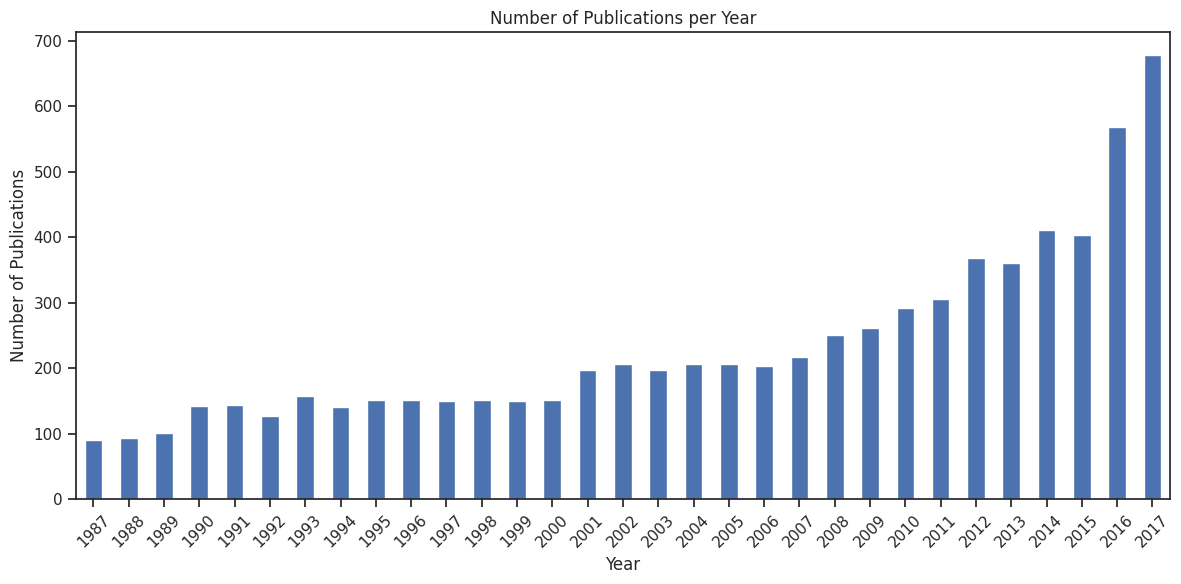

In [ ]:
plt.figure(figsize=(12, 6))
publications_per_year.plot(kind='bar')
plt.title('Number of Publications per Year')
plt.xlabel('Year')
plt.ylabel('Number of Publications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 4: Text data preprocessing

## Text cleaning


In [ ]:
# Converting any uppercase string to lowercase.
df['title'] = df['title'].str.lower()
df['abstract'] = df['abstract'].str.lower()

In [ ]:
df.head()

,year,title,abstract
0,1987,self-organization of associative database and ...,abstract missing
1,1987,a mean field theory of layer iv of visual cort...,abstract missing
2,1988,storing covariance by the associative long-ter...,abstract missing
3,1994,bayesian query construction for neural network...,abstract missing
4,1994,"neural network ensembles, cross validation, an...",abstract missing


In [ ]:
# Removing URL's using the find() method from the Strings :
import re

def find_url(text):
    return text.find("http")

df["find_url_abstract"] = df["abstract"].apply(lambda m: find_url(m))
df["find_url_title"] = df["title"].apply(lambda m: find_url(m))
df

,year,title,abstract,find_url_abstract,find_url_title
0,1987,self-organization of associative database and ...,abstract missing,-1,-1
1,1987,a mean field theory of layer iv of visual cort...,abstract missing,-1,-1
2,1988,storing covariance by the associative long-ter...,abstract missing,-1,-1
3,1994,bayesian query construction for neural network...,abstract missing,-1,-1
4,1994,"neural network ensembles, cross validation, an...",abstract missing,-1,-1
...,...,...,...,...,...
7236,1994,single transistor learning synapses,abstract missing,-1,-1
7237,1994,"bias, variance and the combination of least sq...",abstract missing,-1,-1
7238,1994,a real time clustering cmos neural engine,abstract missing,-1,-1
7239,1994,learning direction in global motion: two class...,abstract missing,-1,-1


In [ ]:
# Removing any noise that might be left: Special characters

import string
def remove_noise(text):
    text = str(text) # Convert input to string to handle potential non-string data
    text = re.sub("(@[A-Za-z0–9_]+)", "", text)
    text = "".join([char if char not in string.punctuation else " " for char in text])
    text = re.sub(" +", " ", text)
    text = re.sub("[0–9]+", "", text)
    text = re.sub("[^A-Za-z0–9_. ]+", "", text)
    return text

df["cleaned_title"] = df["title"].apply(lambda x: remove_noise(x))
df["cleaned_abstract"] = df["abstract"].apply(lambda x: remove_noise(x))
df

,year,title,abstract,find_url_abstract,find_url_title,cleaned_title,cleaned_abstract
0,1987,self-organization of associative database and ...,abstract missing,-1,-1,self organization of associative database and ...,abstract missing
1,1987,a mean field theory of layer iv of visual cort...,abstract missing,-1,-1,a mean field theory of layer iv of visual cort...,abstract missing
2,1988,storing covariance by the associative long-ter...,abstract missing,-1,-1,storing covariance by the associative long ter...,abstract missing
3,1994,bayesian query construction for neural network...,abstract missing,-1,-1,bayesian query construction for neural network...,abstract missing
4,1994,"neural network ensembles, cross validation, an...",abstract missing,-1,-1,neural network ensembles cross validation and ...,abstract missing
...,...,...,...,...,...,...,...
7236,1994,single transistor learning synapses,abstract missing,-1,-1,single transistor learning synapses,abstract missing
7237,1994,"bias, variance and the combination of least sq...",abstract missing,-1,-1,bias variance and the combination of least squ...,abstract missing
7238,1994,a real time clustering cmos neural engine,abstract missing,-1,-1,a real time clustering cmos neural engine,abstract missing
7239,1994,learning direction in global motion: two class...,abstract missing,-1,-1,learning direction in global motion two classe...,abstract missing


## Tokenization

In [ ]:
# Removing stopwords

In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab') # Attempting to download punkt_tab explicitly
nltk.download('punkt') # Keep punkt download as well

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
print("English:\n", stopwords.words("english"))
print("\nSpanish:\n", stopwords.words("spanish"))
print("\nRussian:\n", stopwords.words("russian"))

English:
 ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "sha

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def remove_stop_words(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    text_with_no_stop_words = [
        token for token in tokens if token not in stop_words
    ]
    reformed_text = " ".join(text_with_no_stop_words)

    return reformed_text


df["cleaned_title"] = df["cleaned_title"].apply(
    lambda x: remove_stop_words(x)
)

df["cleaned_abstract"] = df["cleaned_abstract"].apply(
    lambda x: remove_stop_words(x)
)

# Saving clean text to the original columns
df["title"] = df["cleaned_title"]
df["abstract"] = df["cleaned_abstract"]
df = df.drop(["cleaned_title", "cleaned_abstract", "find_url_abstract", "find_url_title", "find_url"], axis=1, errors='ignore')
df

,year,title,abstract
0,1987,self organization associative database applica...,abstract missing
1,1987,mean field theory layer iv visual cortex appli...,abstract missing
2,1988,storing covariance associative long term poten...,abstract missing
3,1994,bayesian query construction neural network models,abstract missing
4,1994,neural network ensembles cross validation acti...,abstract missing
...,...,...,...
7236,1994,single transistor learning synapses,abstract missing
7237,1994,bias variance combination least squares estima...,abstract missing
7238,1994,real time clustering cmos neural engine,abstract missing
7239,1994,learning direction global motion two classes p...,abstract missing


In [ ]:
df["title"].apply(lambda x: word_tokenize(x))
df["abstract"].apply(lambda x: word_tokenize(x))

,abstract
0,"[abstract, missing]"
1,"[abstract, missing]"
2,"[abstract, missing]"
3,"[abstract, missing]"
4,"[abstract, missing]"
...,...
7236,"[abstract, missing]"
7237,"[abstract, missing]"
7238,"[abstract, missing]"
7239,"[abstract, missing]"


In [ ]:
# Calculate the length of the tokenized text
df['title_length'] = df['title'].apply(lambda x: len(x))
df['abstract_length'] = df['abstract'].apply(lambda x: len(x))

display(df.head())

,year,title,abstract,title_length,abstract_length
0,1987,self organization associative database applica...,abstract missing,51,16
1,1987,mean field theory layer iv visual cortex appli...,abstract missing,79,16
2,1988,storing covariance associative long term poten...,abstract missing,95,16
3,1994,bayesian query construction neural network models,abstract missing,49,16
4,1994,neural network ensembles cross validation acti...,abstract missing,57,16


## Stemming




In [ ]:
from nltk import PorterStemmer

sentence = [
    "I",
    "was",
    "thinking",
    "about",
    "geometry",
    "while",
    "I",
    "was",
    "enjoying",
    "the",
    "best",
    "month",
    "of",
    "winter",
]
porterStemmer = PorterStemmer()

print(
    " Sentence:\n",
    sentence,
    "\n\n",
    "Sentence with stemming:\n",
    " ".join([porterStemmer.stem(word) for word in sentence]),
    "\n",
)

 Sentence:
 ['I', 'was', 'thinking', 'about', 'geometry', 'while', 'I', 'was', 'enjoying', 'the', 'best', 'month', 'of', 'winter'] 

 Sentence with stemming:
 i wa think about geometri while i wa enjoy the best month of winter 



In [ ]:
from nltk.stem import PorterStemmer

porterStemmer = PorterStemmer()
df["stemmed_title"] = df["title"].apply(
    lambda text: [porterStemmer.stem(word) for word in text.split()]
)
df["stemmed_abstract"] = df["abstract"].apply(
    lambda text: [porterStemmer.stem(word) for word in text.split()]
)
df

,year,title,abstract,title_length,abstract_length,stemmed_title,stemmed_abstract
0,1987,self organization associative database applica...,abstract missing,51,16,"[self, organ, associ, databas, applic]","[abstract, miss]"
1,1987,mean field theory layer iv visual cortex appli...,abstract missing,79,16,"[mean, field, theori, layer, iv, visual, corte...","[abstract, miss]"
2,1988,storing covariance associative long term poten...,abstract missing,95,16,"[store, covari, associ, long, term, potenti, d...","[abstract, miss]"
3,1994,bayesian query construction neural network models,abstract missing,49,16,"[bayesian, queri, construct, neural, network, ...","[abstract, miss]"
4,1994,neural network ensembles cross validation acti...,abstract missing,57,16,"[neural, network, ensembl, cross, valid, activ...","[abstract, miss]"
...,...,...,...,...,...,...,...
7236,1994,single transistor learning synapses,abstract missing,35,16,"[singl, transistor, learn, synaps]","[abstract, miss]"
7237,1994,bias variance combination least squares estima...,abstract missing,50,16,"[bia, varianc, combin, least, squar, estim]","[abstract, miss]"
7238,1994,real time clustering cmos neural engine,abstract missing,39,16,"[real, time, cluster, cmo, neural, engin]","[abstract, miss]"
7239,1994,learning direction global motion two classes p...,abstract missing,78,16,"[learn, direct, global, motion, two, class, ps...","[abstract, miss]"


## Lemmatization

In [ ]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

sentence = [
    "I",
    "was",
    "thinking",
    "about",
    "geometry",
    "while",
    "I",
    "was",
    "enjoying",
    "the",
    "best",
    "month",
    "of",
    "winter",
]
lemmatizer = WordNetLemmatizer()

print(
    " Sentence:\n",
    sentence,
    "\n\n",
    "Sentence with lemmatizing:\n",
    " ".join([lemmatizer.lemmatize(word) for word in sentence]),
    "\n",
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


 Sentence:
 ['I', 'was', 'thinking', 'about', 'geometry', 'while', 'I', 'was', 'enjoying', 'the', 'best', 'month', 'of', 'winter'] 

 Sentence with lemmatizing:
 I wa thinking about geometry while I wa enjoying the best month of winter 



In [ ]:
from nltk.stem import WordNetLemmatizer

lmtzr = WordNetLemmatizer()
df["lemmatized_title"] = df["title"].apply(
    lambda text: [lmtzr.lemmatize(word) for word in text.split()]
)
df["lemmatized_abstract"] = df["abstract"].apply(
    lambda text: [lmtzr.lemmatize(word) for word in text.split()]
)
df.tail()

,year,title,abstract,title_length,abstract_length,stemmed_title,stemmed_abstract,lemmatized_title,lemmatized_abstract
7236,1994,single transistor learning synapses,abstract missing,35,16,"[singl, transistor, learn, synaps]","[abstract, miss]","[single, transistor, learning, synapsis]","[abstract, missing]"
7237,1994,bias variance combination least squares estima...,abstract missing,50,16,"[bia, varianc, combin, least, squar, estim]","[abstract, miss]","[bias, variance, combination, least, square, e...","[abstract, missing]"
7238,1994,real time clustering cmos neural engine,abstract missing,39,16,"[real, time, cluster, cmo, neural, engin]","[abstract, miss]","[real, time, clustering, cmos, neural, engine]","[abstract, missing]"
7239,1994,learning direction global motion two classes p...,abstract missing,78,16,"[learn, direct, global, motion, two, class, ps...","[abstract, miss]","[learning, direction, global, motion, two, cla...","[abstract, missing]"
7240,1994,correlation interpolation networks real time e...,abstract missing,74,16,"[correl, interpol, network, real, time, expres...","[abstract, miss]","[correlation, interpolation, network, real, ti...","[abstract, missing]"


# Step 5: Bag of Words representation

In [ ]:
df = df[["title", "abstract"]]
df

,title,abstract
0,self organization associative database applica...,abstract missing
1,mean field theory layer iv visual cortex appli...,abstract missing
2,storing covariance associative long term poten...,abstract missing
3,bayesian query construction neural network models,abstract missing
4,neural network ensembles cross validation acti...,abstract missing
...,...,...
7236,single transistor learning synapses,abstract missing
7237,bias variance combination least squares estima...,abstract missing
7238,real time clustering cmos neural engine,abstract missing
7239,learning direction global motion two classes p...,abstract missing


In [ ]:
df_list = list(df["title"].values)
abstract = df["abstract"].values

In [ ]:
df_list[:10]

['self organization associative database applications',
 'mean field theory layer iv visual cortex application artificial neural networks',
 'storing covariance associative long term potentiation depression synaptic strengths hippocampus',
 'bayesian query construction neural network models',
 'neural network ensembles cross validation active learning',
 'using neural net instantiate deformable model',
 'plasticity mediated competitive learning',
 'iceg morphology classification using analogue vlsi neural network',
 'real time control tokamak plasma using neural networks',
 'pulsestream synapses non volatile analogue amorphous silicon memories']

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Getting the words
all_words = count_vectorizer.get_feature_names_out()

# Visualizing the first 50 words
print(all_words[:50])

['ability' 'able' 'abrupt' 'absence' 'absent' 'absolute' 'absorbing'
 'abstain' 'abstention' 'abstract' 'abstraction' 'ac' 'accelerate'
 'accelerated' 'accelerates' 'accelerating' 'acceleration' 'accepted'
 'access' 'accessible' 'accommodate' 'accomplish' 'accomplished'
 'according' 'accordingly' 'account' 'accounting' 'accumulate'
 'accumulated' 'accuracy' 'accurate' 'accurately' 'achievable' 'achieve'
 'achieved' 'achieves' 'achieving' 'acnn' 'acoustic' 'acquire' 'acquired'
 'acquiring' 'acquisition' 'across' 'act' 'acting' 'action' 'activation'
 'active' 'actively']


# Step 6: Word Clouds

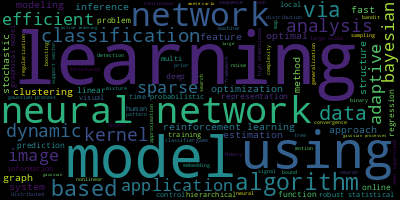

In [ ]:
# Import the wordcloud library
import wordcloud
# Join the different processed titles together.
long_string = " ".join(df['title'])
# Create a WordCloud object
wordcloud = wordcloud.WordCloud()
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()

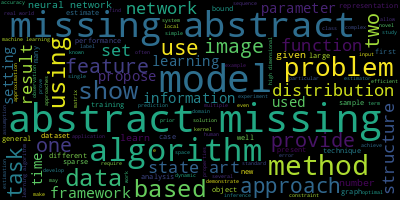

In [ ]:
# Import the wordcloud library
import wordcloud
# Join the different processed titles together.
long_string = " ".join(df['abstract'])
# Create a WordCloud object
wordcloud = wordcloud.WordCloud()
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()